Deutsch Circuit - Balanced Function f(x)=x


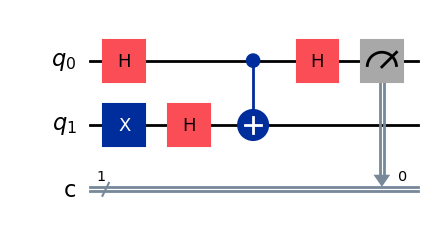

Measurement results: {'1': 1024}
Result: 1 → BALANCED


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# MEDIUM: Deutsch Algorithm for balanced function f(x) = x
# ---------------------------------------------------------

simulator = AerSimulator()

qc = QuantumCircuit(2, 1)

# Step 1: Input qubit |+>
qc.h(0)

# Step 2: Ancilla |1> -> |->
qc.x(1)
qc.h(1)

# ---------------------------------------------------------
# Oracle for f(x) = x
# ---------------------------------------------------------
# f(x)=x means apply CNOT
# Control = input qubit q0
# Target  = ancilla q1

qc.cx(0, 1)

# Step 4: Hadamard on input qubit
qc.h(0)

# Step 5: Measure input
qc.measure(0, 0)

# Display circuit
print("Deutsch Circuit - Balanced Function f(x)=x")
display(qc.draw("mpl"))

# Run
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Measurement results:", counts)

# Histogram
plot_histogram(counts)
plt.show()

# Determine result
if counts.get("0", 0) > counts.get("1", 0):
    print("Result: 0 → CONSTANT")
else:
    print("Result: 1 → BALANCED")